<a href="https://colab.research.google.com/github/gabrielebirri/CLAMA_Project/blob/main/Pipeline_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Melanoma identification through deep transfer learning**  

Author: Gabriele Birri  
Date: March 2026


## Introduction  
### Abstract
The objective of this experimental research is to conduct a comparative analysis of diverse Convolutional Neural Network (CNN) architectures to assess their performance in the automated classification of cutaneous lesions as benign or malignant (melanoma). Given the inherent constraints of medical imaging datasets, a transfer learning methodology is adopted. Specifically, three prominent architectures, pre-trained on the ImageNet database, are employed as feature extractors to evaluate their diagnostic efficacy. To ensure experimental integrity and mitigate methodological biases, a standardized training and evaluation pipeline is maintained across all models.

The architectures are adapted for binary classification by substituting the original global classifier or fully connected layer with a task-specific head. The optimization follows a two-phase fine-tuning strategy: an initial stage where the convolutional backbone remains frozen to stabilize the new classifier's weights, followed by a selective unfreezing of deeper layers to facilitate domain-specific feature adaptation. This dual-stage approach is designed to enhance task specialization while preserving the generalization capabilities of the pre-trained weights. Furthermore, a grad-CAM technique is implemented to gain a sensible evidence of the spatial attention of the model.

The study utilizes a dataset of approximately 10,000 dermoscopic images, sourced from a publicly available repository and balanced between benign and malignant classes. The performance of the respective architectures is rigorously quantified using standard clinical evaluation metrics, providing a comprehensive perspective on the suitability of different CNN backbones for computer-aided diagnosis in dermatology.  

**Dataset used:** https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images

### The Significance of early Melanoma Detection
Melanoma is a malignant neoplasm arising from the oncogenic transformation of melanocytes, the pigment-producing cells located in the basal layer of the epidermis. While it accounts for a minority of skin cancer cases, it is responsible for the vast majority of skin cancer-related fatalities due to its aggressive nature and high metastatic potential. Precision and speed in diagnosis are paramount; according to the American Cancer Society (2025), the 5-year survival rate exceeds 99% when detected at a localized stage, but plummets to approximately 35% once distant metastasis occurs. Consequently, developing automated, highly accurate diagnostic tools is a critical priority in reducing clinical variability and improving patient outcomes through early intervention.

**Key References**
* American Cancer Society. (2025). Cancer Facts & Figures 2025. Atlanta: American Cancer Society.  

* Haenssle, M. A., et al. (2018). Man against machine: diagnostic performance of a deep learning convolutional neural network for dermoscopic melanoma recognition in comparison to 58 dermatologists. Annals of Oncology, 29(8), 1836-1842.  

* World Health Organization. (2024). Global Cancer Statistics: Skin Melanoma.


In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Detected environment: Colab")
    print("Proceeding to download grad-cam library")
    !pip install grad-cam -q
    !git clone https://github.com/gabrielebirri/CLAMA_Project

else:
    print("Detected environment: Local")

Detected environment: Local


In [2]:
## IMPORT PACKAGES ##

# Utility
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tqdm import tqdm
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
import copy
import shutil
import sys

# Functions
from src.utils import download_dataset
from src.utils import im_show

# PyTorch
import torch
from torch import nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


print("all clear")

all clear


In [3]:
# Setting up the agnostic device code
if torch.backends.mps.is_available():
    device = "mps"  # For MPS acceleration
elif torch.cuda.is_available():
    device = "cuda" # For CUDA acceleration
else:
    device = "cpu"

print(f"Device: {device}")

Device: mps


# Pre-processing of the image data

**Data augmentation**

To improve the generalization capability of the model and mitigate overfitting, a data augmentation strategy is applied to the training dataset. The selected transformations are carefully chosen to preserve the clinically relevant diagnostic features of melanoma while introducing controlled variability in the input images.

The transformations employed include resizing, horizontal flipping, vertical flipping and rotation. Image resizing standardizes the input dimensions to match the architectural requirements of the neural network, ensuring consistent tensor shapes across the dataset. Horizontal and vertical flips are applied to simulate variations in lesion orientation. Since melanoma diagnosis is independent of the spatial orientation of the lesion, these transformations do not alter essential diagnostic criteria such as asymmetry, border irregularity, color heterogeneity, or structural patterns. Similarly, controlled rotations are introduced to further increase rotational invariance, reflecting the fact that skin lesions may be photographed from different angles without affecting their pathological characteristics.

It's important to note that no transformations that could distort morphological or chromatic properties are applied. The selected augmentations preserve the intrinsic geometrical and textural features that are critical for melanoma identification, thereby maintaining clinical validity while enhancing model robustness.

**Image normalization**

To minimize the objective function more efficiently and maintain architectural consistency with the pre-trained EfficientNetV2-S backbone, a Z-score normalization was applied. This transformation centers the pixel intensity distribution around zero and scales it to unit variance, preventing gradient instability and ensuring that the visual features extracted are robust to varying lighting conditions of the source mobile devices.

**Dataset splitting**

The dataset is splitted into three subsets (of approximately the sizes indicated):

* Training (80%)  

* Validation (10%)  

* Test (10%)  

The training set is used to optimize the model parameters through backpropagation. The validation set is employed during development to tune hyperparameters, monitor generalization performance, and implement strategies such as early stopping. The test set, which remains completely unseen during training and validation, is used exclusively for the final performance evaluation to provide an unbiased estimate of the model’s predictive capability on new data.
This structured splitting ensures methodological rigor and prevents information leakage, thereby supporting reliable assessment of the model’s real-world applicability.

In [4]:
IN_COLAB = 'google.colab' in sys.modules

train_path, test_path = download_dataset(IN_COLAB)

print(train_path)

Detected environment: Local
/Users/gabrielebirri/.cache/kagglehub/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images/versions/1/melanoma_cancer_dataset/train


In [5]:
from src.transforms import train_transform, test_transform

# Building the train dataset using ImageFolder
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

# Building validation and test datasets using ImageFolder
test_validation_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

targets = test_validation_dataset.targets

val_indices, test_indices = train_test_split(
    range(len(test_validation_dataset)),
    test_size=0.5,
    stratify=targets,
    random_state=42
)

validation_dataset = torch.utils.data.Subset(test_validation_dataset, val_indices)
test_dataset = torch.utils.data.Subset(test_validation_dataset, test_indices)

print(train_dataset.class_to_idx)
print(len(train_dataset))
print(len(validation_dataset))
print(len(test_dataset))

{'benign': 0, 'malignant': 1}
9605
500
500


Benign


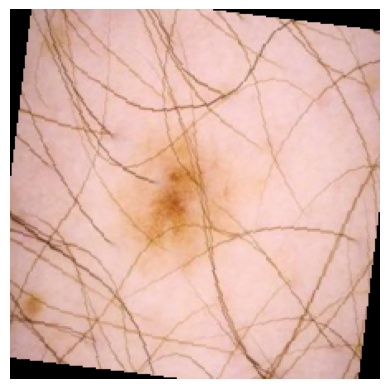

In [6]:
# Let's visualize a sample of our train dataset
# Each image comes in a [3,224,224] shape, or the standard [C,H,W]

img, label = train_dataset[1508]    # Visualized tensor
im_show(img)

if label == 0:
  print("Benign")
else:
  print("Malignant")

In [7]:
# DATA LOADERS
batch_size = 32

# This will allow to load the dataset in batches

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# For the validation and test datasets, shuffling is not needed
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model choice and methods
**Choice of the model**  
In this notebook we are going to compare different models in order to assess differences in performance between them and optimize the choice for the best models. We are going to evaluate:  

* DenseNet121: widely adopted in the medical imaging literature for melanoma classification due to its strong capability to capture fine-grained visual patterns and subtle chromatic variations, which are critical diagnostic features in this task.  

* ResNet50  

* EfficientNet  

**Training phase**

We are going to divide the training phase in two subfases:  

*   Training of the classifier (3-7 epochs)  

*   Fine tuning of the backbone (10-15 epochs)  

The reason for this particular choice lays in the pre-training of our chosen model: if we update all the parameters already in the first epochs we may run into the destruction of the basic feature recognition learned through pre-training using ImageNet (a much larger dataset than the one we used); this phenomenon is called catastrophic forgetting.    
The optimal fine tuning of the model will thus consist first in the training of the classifier, and then in the fine tuning of the actual backbone of the CNN model.

**Optimizer:**
The choice of ADAM as optimizer is driven by the necessity of the detection of fairy small features. In this task Adam thrives the most because of its stunning gradient adaptation. In the second phase of the training ADAM will be replaced by SGD in order to limit oscillations and achieving a better convergence.


In [8]:
from src.utils import build_densenet, build_efficientnet, build_resnet

# Choosing the model to evaluate
model_name = "EfficientNet" # Namecode for the device

# Downloading and preparing the model
if model_name == "DenseNet121":
    model = build_densenet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "ResNet50":
    model = build_resnet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "EfficientNet":
    model = build_efficientnet()
    print(f"Model: {model_name}_v2_s \nStatus: Loaded correctly")

model = model.to(device) # Moving the model to selected device

Model: EfficientNet_v2_s 
Status: Loaded correctly


# Training pipeline

Despite the choice of the model, the training and testing pipelines will follow the same procedures, in order to not create experimental biases and to better confront models and their performances.

In [9]:
# CRITERION
# The loss function is set up to have an higher penalization on malignant
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.2]).to(device))

# Learning rate
learning_rate = 0.001

# OPTIMIZER
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# First raining phase

from src.utils import freeze_backbone, unfreeze_backbone
from src.training import training_loop

freeze_backbone(model)

epochs = 5
threshold = 0.4

training_loop(epochs=epochs, threshold=threshold, model=model, train_loader=train_loader, val_loader=val_loader, device=device, criterion=criterion, optimizer=optimizer)

### Second training phase

In this phase we are going to unfreeze the backbone in order to perform backpropagation through the whole model weights. It is important to limit the size of this phase in order to avoid destroying basic feature recognition as explained before. In this phase we are going to use the stochastic gradient descent (SGD) to enhance robustness on solution convergence and avoiding oscillations. We are going to implement the SDG with a momentum and a weight decay for better performances

In [ ]:
# Choosing SGD as optimizer for robustness
# Learning rate
learning_rate = 1e-4
momentum = 0.9
weight_decay = 1e-4

# OPTIMIZER
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

In [ ]:
# Second training phase

# NOW THE BACKBONE IS UNFREEZED
unfreeze_backbone(model)

epochs = 15
threshold = 0.4

training_loop(epochs=epochs, threshold=threshold, model=model, train_loader=train_loader, val_loader=val_loader, device=device, criterion=criterion, optimizer=optimizer)

## Saving the model

In [ ]:
# Defining paths
models_path = Path('./models')
models_path.mkdir(parents=True, exist_ok=True)
save_path = models_path / "Clama_v0.pth"
load_path = models_path / "Clama_v0.pth"

In [ ]:
# Saving state dict of the model
torch.save(model.state_dict(), save_path)
print(f"Model saved in: {save_path}")